* This notebook compares ARIMA(2,1,0), ETS(A,N,N), and Prophet forecasts for the NASDAQ (^IXIC).

* Accuracy is evaluated using MAE, RMSE, and MAPE for 5-day, 1-month, and 1-year horizons.

In [25]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

try:
    from prophet import Prophet
except Exception:
    from fbprophet import Prophet

In [27]:
df = pd.read_csv("../data/ixic.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)

y = df["^IXIC"].astype(float).sort_index()
y.name = "ixic_close"

print("Series type:", type(y))
print("Start:", y.index.min().date(), "End:", y.index.max().date())
print("Observations:", len(y))
print("Missing:", int(y.isna().sum()))
print("Weekend rows:", int((y.index.dayofweek >= 5).sum()))

y = y.asfreq("B").ffill()

Series type: <class 'pandas.core.series.Series'>
Start: 2016-01-04 End: 2026-02-20
Observations: 2548
Missing: 0
Weekend rows: 0


In [29]:
def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    eps = 1e-9
    return float(np.mean(np.abs((y_true - y_pred) /
                 (np.maximum(np.abs(y_true), eps)))) * 100)

def score_model(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }

In [31]:
H = 5
train = y.iloc[:-H]
test = y.iloc[-H:]

print("Train:", train.index.min().date(), "->", train.index.max().date(), "| n =", len(train))
print("Test :", test.index.min().date(), "->", test.index.max().date(), "| n =", len(test))

Train: 2016-01-04 -> 2026-02-13 | n = 2640
Test : 2026-02-16 -> 2026-02-20 | n = 5


In [33]:
ARIMA_ORDER = (2, 1, 0)

y_log_train = np.log(train)
arima_fit = ARIMA(y_log_train, order=ARIMA_ORDER).fit()

arima_fc_log = arima_fit.get_forecast(steps=H).predicted_mean
arima_fc = np.exp(arima_fc_log.values)

arima_pred = pd.Series(arima_fc, index=test.index, name="ARIMA_pred")

In [35]:
ets_fit = ExponentialSmoothing(
    train,
    trend=None,
    seasonal=None,
    initialization_method="estimated"
).fit(optimized=True)

ets_fc = ets_fit.forecast(H)
ets_pred = pd.Series(ets_fc.values, index=test.index, name="ETS_pred")

In [37]:
prophet_df = pd.DataFrame({"ds": train.index, "y": train.values})

m = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

m.fit(prophet_df)

future = pd.DataFrame({"ds": test.index})
fcst = m.predict(future)

prophet_pred = pd.Series(fcst["yhat"].values, index=test.index, name="Prophet_pred")

04:46:21 - cmdstanpy - INFO - Chain [1] start processing
04:46:21 - cmdstanpy - INFO - Chain [1] done processing


In [39]:
pred_table = pd.DataFrame({
    "Actual": test,
    "ARIMA": arima_pred,
    "ETS": ets_pred,
    "Prophet": prophet_pred
})

display(pred_table)

results = []
results.append(score_model("ARIMA(2,1,0)", test.values, arima_pred.values))
results.append(score_model("ETS(A,N,N)", test.values, ets_pred.values))
results.append(score_model("Prophet", test.values, prophet_pred.values))

metrics = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

display(metrics)

,Actual,ARIMA,ETS,Prophet
Date,,,,
2026-02-16,22546.669922,22530.256656,22553.002035,23409.712749
2026-02-17,22578.380859,22529.747032,22553.002035,23407.343775
2026-02-18,22753.630859,22529.016921,22553.002035,23409.263991
2026-02-19,22682.730469,22529.077626,22553.002035,23392.654749
2026-02-20,22886.070312,22529.035402,22553.002035,23382.238062


,Model,MAE,RMSE,MAPE_%
0,"ETS(A,N,N)",139.027295,183.684539,0.609898
1,"ARIMA(2,1,0)",160.069757,202.073843,0.702561
2,Prophet,710.746181,722.779656,3.135706


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_horizon(y, H, arima_order=(2,1,0)):

    train = y.iloc[:-H]
    test = y.iloc[-H:]

    print("\n======================================")
    print(f"Horizon = {H} trading days")
    print("Train:", train.index.min().date(), "->", train.index.max().date(), "| n =", len(train))
    print("Test :", test.index.min().date(), "->", test.index.max().date(), "| n =", len(test))

    # ETS
    ets_model = ExponentialSmoothing(train, trend="add", seasonal=None)
    ets_fit = ets_model.fit(optimized=True)
    ets_pred = pd.Series(ets_fit.forecast(H).values, index=test.index)

    # ARIMA
    arima_model = ARIMA(train, order=arima_order)
    arima_fit = arima_model.fit()
    arima_pred = pd.Series(arima_fit.forecast(H).values, index=test.index)

    # Prophet
    prophet_df = train.reset_index()
    prophet_df.columns = ["ds","y"]

    m = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=True)
    m.fit(prophet_df)

    future = m.make_future_dataframe(periods=H, freq="B")
    fcst = m.predict(future)

    prophet_pred = pd.Series(
        fcst.set_index("ds")["yhat"].iloc[-H:].values,
        index=test.index
    )

    def score(name, actual, pred):
        mae = mean_absolute_error(actual, pred)
        rmse = np.sqrt(mean_squared_error(actual, pred))
        mape = np.mean(np.abs((actual - pred) / actual)) * 100
        return [name, mae, rmse, mape]

    results = pd.DataFrame([
        score("ARIMA", test.values, arima_pred.values),
        score("ETS", test.values, ets_pred.values),
        score("Prophet", test.values, prophet_pred.values)
    ], columns=["Model","MAE","RMSE","MAPE_%"]).sort_values("RMSE")

    display(results)
    return results

In [43]:
results_1m = evaluate_horizon(y, H=21)
results_1y = evaluate_horizon(y, H=252)


Horizon = 21 trading days
Train: 2016-01-04 -> 2026-01-22 | n = 2624
Test : 2026-01-23 -> 2026-02-20 | n = 21


04:47:22 - cmdstanpy - INFO - Chain [1] start processing
04:47:23 - cmdstanpy - INFO - Chain [1] done processing


,Model,MAE,RMSE,MAPE_%
0,ARIMA,469.040499,551.026307,2.050765
2,Prophet,525.421852,581.345598,2.285087
1,ETS,574.592245,682.653939,2.515156


04:47:23 - cmdstanpy - INFO - Chain [1] start processing



Horizon = 252 trading days
Train: 2016-01-04 -> 2025-03-05 | n = 2393
Test : 2025-03-06 -> 2026-02-20 | n = 252


04:47:24 - cmdstanpy - INFO - Chain [1] done processing


,Model,MAE,RMSE,MAPE_%
2,Prophet,1192.872298,1607.517065,6.310176
0,ARIMA,3020.209669,3426.450188,13.756048
1,ETS,4832.741740,5609.387430,21.746389


In [45]:
import matplotlib.pyplot as plt

def plot_horizon(y, horizon, title, window=None):

    train = y.iloc[:-horizon]
    test = y.iloc[-horizon:]
    last_train_date = train.index[-1]
    last_train_val = float(train.iloc[-1])

    future_index = pd.bdate_range(
        start=last_train_date + pd.offsets.BDay(1),
        periods=horizon
    )

    # ARIMA
    arima_fit = ARIMA(train, order=(2,1,0)).fit()
    arima_pred = pd.Series(arima_fit.forecast(steps=horizon).values, index=future_index)

    # ETS
    ets_fit = ExponentialSmoothing(train, trend="add", seasonal=None).fit()
    ets_pred = pd.Series(ets_fit.forecast(horizon).values, index=future_index)

    # Prophet
    prophet_df = train.reset_index()
    prophet_df.columns = ["ds","y"]
    m = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
    m.fit(prophet_df)
    forecast = m.predict(pd.DataFrame({"ds": future_index}))
    prophet_pred = pd.Series(forecast["yhat"].values, index=future_index)

    fc_index = pd.DatetimeIndex([last_train_date]).append(future_index)
    arima_plot = pd.Series([last_train_val] + arima_pred.tolist(), index=fc_index)
    ets_plot = pd.Series([last_train_val] + ets_pred.tolist(), index=fc_index)
    prophet_plot = pd.Series([last_train_val] + prophet_pred.tolist(), index=fc_index)

    if window is None:
        if horizon <= 5:
            window = 30
        elif horizon <= 21:
            window = 90
        else:
            window = 300

    zoom_start = train.index[-min(window, len(train))]
    train_plot = train.loc[zoom_start:]
    test_plot = test.loc[zoom_start:]

    plt.figure(figsize=(12,6))
    plt.plot(train_plot.index, train_plot.values, linewidth=2.5, label="Training")
    plt.plot(test_plot.index, test_plot.values, linewidth=2.5, label="Actual")

    plt.plot(arima_plot.index, arima_plot.values, linestyle="--", linewidth=2.5, label="ARIMA")
    plt.plot(ets_plot.index, ets_plot.values, linestyle="--", linewidth=2.5, label="ETS")
    plt.plot(prophet_plot.index, prophet_plot.values, linestyle="--", linewidth=2.5, label="Prophet")

    plt.axvline(last_train_date, linestyle=":", linewidth=1.6)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("NASDAQ (^IXIC)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

04:48:09 - cmdstanpy - INFO - Chain [1] start processing
04:48:09 - cmdstanpy - INFO - Chain [1] done processing


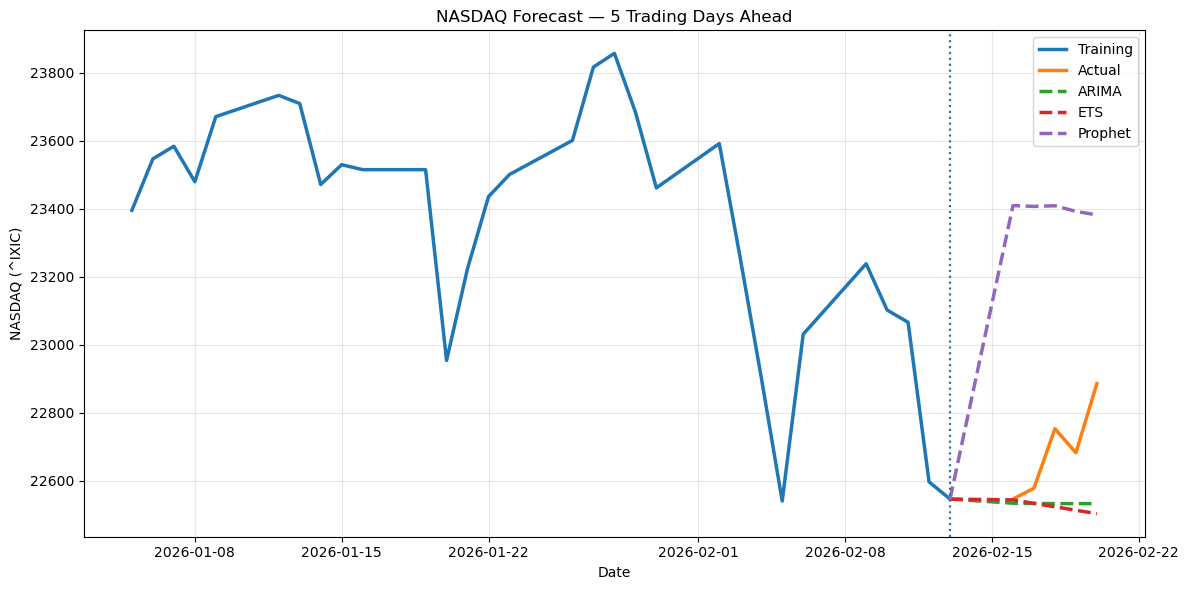

04:48:10 - cmdstanpy - INFO - Chain [1] start processing
04:48:10 - cmdstanpy - INFO - Chain [1] done processing


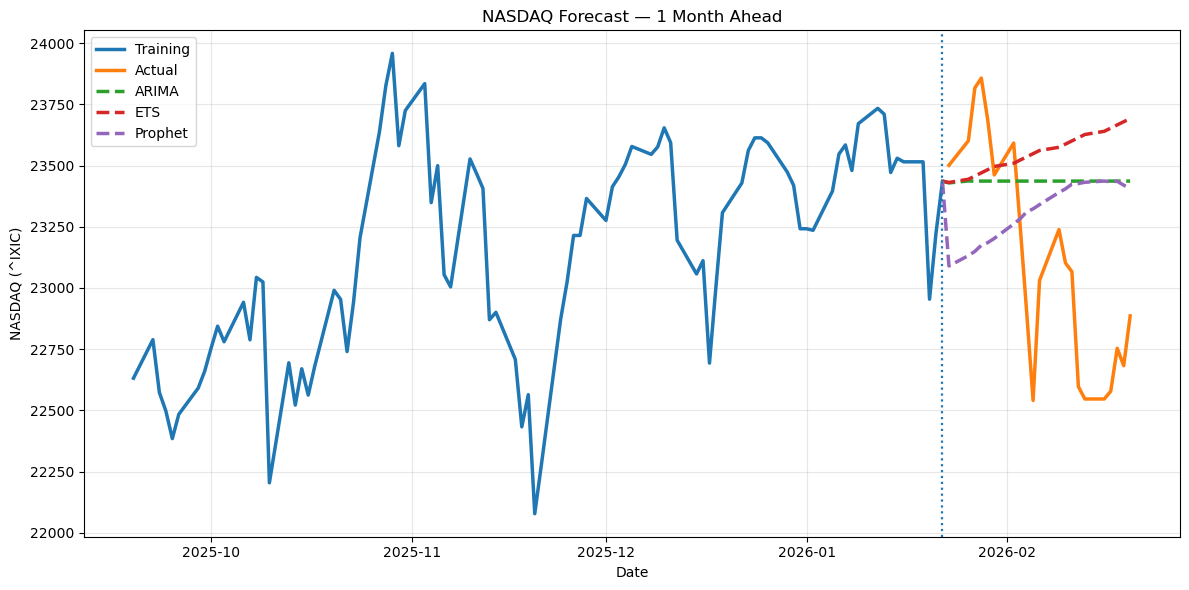

04:48:11 - cmdstanpy - INFO - Chain [1] start processing
04:48:11 - cmdstanpy - INFO - Chain [1] done processing


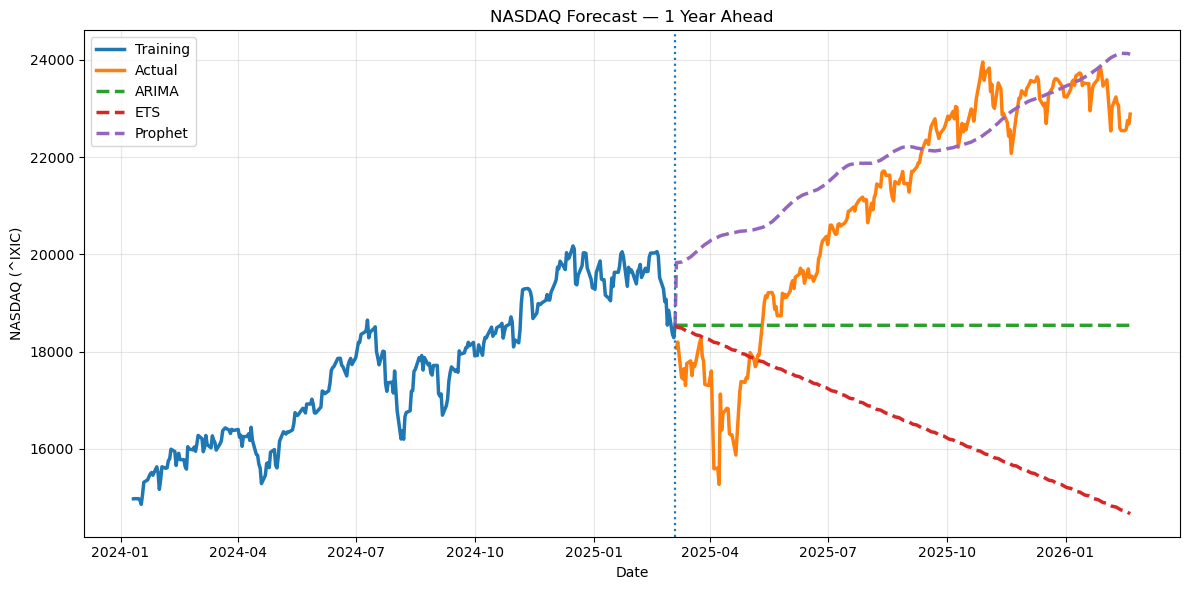

In [47]:
plot_horizon(y, 5, "NASDAQ Forecast — 5 Trading Days Ahead")
plot_horizon(y, 21, "NASDAQ Forecast — 1 Month Ahead")
plot_horizon(y, 252, "NASDAQ Forecast — 1 Year Ahead")

### Forecasting Model Comparison — Conclusion

The NASDAQ (^IXIC) daily closing index (2016–2026) was forecasted using three models: **ARIMA(2,1,0)**, **ETS(A,N,N)**, and **Prophet**.
Forecast accuracy was evaluated with **MAE, RMSE, and MAPE** for different forecast horizons.

---

#### 5 Trading Days

| Model          | MAE     | RMSE    | MAPE      |
| -------------- | ------- | ------- | --------- |
| **ETS(A,N,N)** | **139** | **184** | **0.61%** |
| ARIMA(2,1,0)   | 160     | 202     | 0.70%     |
| Prophet        | 711     | 723     | 3.14%     |


Over very short horizons, prices mostly follow the most recent level. Exponential smoothing adapts fastest to the last observed value, while trend-based models overreact.

---

#### 1 Month

| Model            | MAE     | RMSE    | MAPE      |
| ---------------- | ------- | ------- | --------- |
| **ARIMA(2,1,0)** | **469** | **551** | **2.05%** |
| Prophet          | 525     | 581     | 2.29%     |
| ETS(A,N,N)       | 575     | 683     | 2.52%     |


At this horizon the index shows short-term autocorrelation and momentum. ARIMA captures these dynamics through differencing and autoregressive structure, while ETS reacts too slowly and Prophet focuses on longer-term movement.

---

#### 1 Year

| Model        | MAE      | RMSE     | MAPE      |
| ------------ | -------- | -------- | --------- |
| **Prophet**  | **1193** | **1608** | **6.31%** |
| ARIMA(2,1,0) | 3020     | 3426     | 13.76%    |
| ETS(A,N,N)   | 4833     | 5609     | 21.75%    |


Over long periods the index follows a gradual upward trend. Prophet models structural growth, while ARIMA accumulates forecast error and ETS lacks a trend component.

---

### Overall Finding

Forecast performance depends on the prediction horizon:

* **Short-term:** ETS(A,N,N)
* **Medium-term:** ARIMA(2,1,0)
* **Long-term:** Prophet

No single model is optimal for all horizons; each captures a different component of market behavior (short-run level, medium-run dynamics, and long-run trend).
